# Ejemplos de codigo - Adult

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro

import statsmodels.api as sm

In [3]:
sns.set_theme(style="whitegrid")


In [4]:
# Cargar datos
data = pd.read_csv("abalone.csv", na_values="?") # Se incluye na_values para marcar "?" como faltante

In [5]:
# 1) Informacion basica (filas, columnas)
data.shape

(4177, 9)

In [6]:
# 2) Revision inicial
data.head()


,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [8]:
# 3c) Variables de trabajo (detectadas automaticamente por tipo)
vars_categoricas = data.select_dtypes(include=["object", "category", "bool", "string"]).columns.tolist()
vars_numericas = data.select_dtypes(include=[np.number]).columns.tolist()
print("Variables categóricas:", vars_categoricas)
print("Variables numéricas:", vars_numericas)

Variables categóricas: ['Sex']
Variables numéricas: ['Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'Rings']


In [9]:
# 12) Matriz de correlacion
cor_mat = data[vars_numericas].corr(numeric_only=True)
cor_mat


,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
Length,1.000000,0.986812,0.827554,0.925261,0.897914,0.903018,0.897706,0.556720
Diameter,0.986812,1.000000,0.833684,0.925452,0.893162,0.899724,0.905330,0.574660
Height,0.827554,0.833684,1.000000,0.819221,0.774972,0.798319,0.817338,0.557467
Whole_weight,0.925261,0.925452,0.819221,1.000000,0.969405,0.966375,0.955355,0.540390
Shucked_weight,0.897914,0.893162,0.774972,0.969405,1.000000,0.931961,0.882617,0.420884
Viscera_weight,0.903018,0.899724,0.798319,0.966375,0.931961,1.000000,0.907656,0.503819
Shell_weight,0.897706,0.905330,0.817338,0.955355,0.882617,0.907656,1.000000,0.627574
Rings,0.556720,0.574660,0.557467,0.540390,0.420884,0.503819,0.627574,1.000000


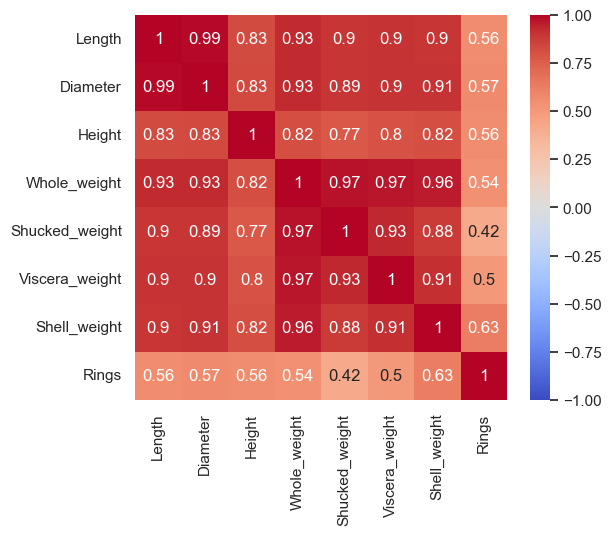

In [14]:
# 12) Heatmap correlacion
plt.figure(figsize=(6, 5))
sns.heatmap(cor_mat, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.show()


<Axes: xlabel='Shell_weight', ylabel='Rings'>

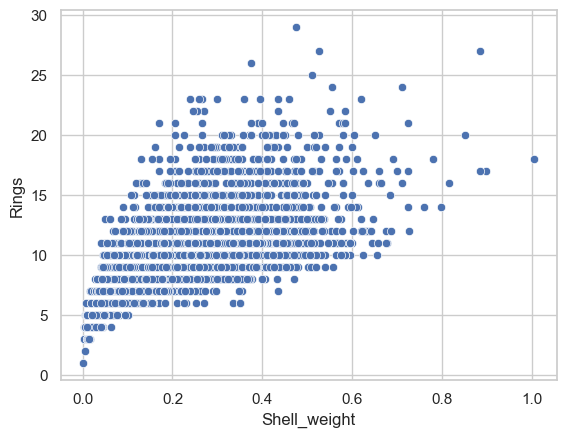

In [15]:
sns.scatterplot(y="Rings", x="Shell_weight", data=data)

In [18]:
reglin = sm.formula.ols("Rings ~ Shell_weight", data=data)

In [19]:
results = reglin.fit()

In [20]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Rings   R-squared:                       0.394
Model:                            OLS   Adj. R-squared:                  0.394
Method:                 Least Squares   F-statistic:                     2713.
Date:                Fri, 03 Apr 2026   Prob (F-statistic):               0.00
Time:                        00:33:34   Log-Likelihood:                -9770.8
No. Observations:                4177   AIC:                         1.955e+04
Df Residuals:                    4175   BIC:                         1.956e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        6.4621      0.077     83.764      0.000       6.311       6.613
Shell_weight    14.5357      0.279     52.084      0.000      13.989      15.083
==============================================================================
Omnibus:                     1213.646   Durbin-Watson:                   1.016
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3601.423
Skew:                           1.503   Prob(JB):                         0.00
Kurtosis:                       6.414   Cond. No.                         7.60
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Rings = 6.4621 + 14.5357 * Shell_weight

In [22]:
# Estimar valores predichos
data["Rings_pred_reglin"] = 6.4621 + 14.5357 * data["Shell_weight"]
data["Rings_pred_media"] = data["Rings"].mean()

In [23]:
data["Rings_pred_reglin_resid"] = (data["Rings"] - data["Rings_pred_reglin"]) ** 2
data["Rings_pred_media_resid"] = (data["Rings"] - data["Rings_pred_media"]) ** 2

In [24]:
ss_reglin = data["Rings_pred_reglin_resid"].sum()
ss_media = data["Rings_pred_media_resid"].sum()

In [25]:
1 - (ss_reglin / ss_media)

np.float64(0.3938491813308066)